# Part 9: Optax Optimization

In [1]:
# @title Setup { display-mode: "form" }

import jax
import jax.numpy as jnp
import numpy as np
import flax.linen as nn
import optax
import matplotlib.pyplot as plt

print(f"JAX version:     {jax.__version__}")
print(f"Devices:         {jax.devices()}")
print(f"Default backend: {jax.default_backend()}")

JAX version:     0.9.2
Devices:         [CpuDevice(id=0)]
Default backend: cpu


In [2]:
# @title Shared Data and Model from Notebooks 07-08 { display-mode: "form" }

key = jax.random.key(42)

def make_moons(n_samples=1000, noise=0.15, seed=0):
    rng = np.random.default_rng(seed)
    n = n_samples // 2
    t = np.linspace(0, np.pi, n)
    X0 = np.c_[np.cos(t), np.sin(t)]
    X1 = np.c_[1 - np.cos(t), 1 - np.sin(t) - 0.5]
    X = np.vstack([X0, X1]) + rng.normal(scale=noise, size=(n_samples, 2))
    y = np.hstack([np.zeros(n), np.ones(n)])
    return X.astype(np.float32), y.astype(np.float32)

X_np, y_np = make_moons(n_samples=1000, noise=0.15, seed=0)
X = jnp.array(X_np)
y = jnp.array(y_np)

# Flax model from Notebook 08
class MLP(nn.Module):
    hidden_sizes: tuple
    out_size: int = 1

    @nn.compact
    def __call__(self, x):
        for h in self.hidden_sizes:
            x = nn.Dense(h)(x)
            x = nn.relu(x)
        return nn.Dense(self.out_size)(x).squeeze(-1)

model = MLP(hidden_sizes=(64, 64))
x_dummy = jnp.ones((1, 2))

# Initialize model
key, subkey = jax.random.split(key)
variables = model.init(subkey, x_dummy)
params_flax = variables['params']

# Loss function from Notebook 08
def loss_flax(params, x_batch, y_batch):
    logits = model.apply({'params': params}, x_batch)
    return jnp.mean(
        jnp.maximum(logits, 0) - logits * y_batch + jnp.log(1 + jnp.exp(-jnp.abs(logits)))
    )


print(f"Model and dataset ready. params leaves: {len(jax.tree.leaves(params_flax))}")

Model and dataset ready. params leaves: 6


---

# 1. Training with Optax

Plain SGD with a fixed learning rate is the simplest update rule, but real training almost always uses a smarter variant. The most common is **Adam**: it keeps a per-weight running average of recent gradients and a running estimate of their variance, and uses both to scale each weight's update.

**Optax** is JAX's optimizer library. It provides:
- **Adam** and **AdamW** (Adam plus weight decay, a regularization trick).

- **SGD with momentum**, where each step is a blend of the new gradient and the previous step's direction.

- **Learning-rate schedules**: rules for changing the step size over training (e.g., warmup then cosine decay).

- **Gradient clipping** and other gradient transformations.

## 1.1 The Optax Protocol

Optax optimizers follow a two-step functional pattern:

```python
optimizer = optax.adam(learning_rate=1e-3)       # define the optimizer
opt_state = optimizer.init(params)                # initialize optimizer state
                                                  # (e.g. Adam's moment estimates)

# In the training step:
updates, new_opt_state = optimizer.update(grads, opt_state)
new_params             = optax.apply_updates(params, updates)
```

`opt_state` is itself a pytree. For Adam, it contains the running average of gradients (m), the running estimate of squared gradients (v), and the current step number. Each of those mirrors the shape of `params`. You pass `opt_state` into `optimizer.update` and store the returned `new_opt_state` for next step. Optax never holds state inside an object behind your back; it's all in `opt_state`.

```
  Initial setup (once):
     params ──► optimizer.init(params) ──► opt_state₀

  Per training step:

     ┌──────────────────── carry across steps ───────────────────┐
     │                                                            │
     ▼                                                            │
   opt_state ──┐                                                  │
               ├──► optimizer.update(grads, opt_state) ──► updates, new_opt_state
   grads ──────┘                                                  │
                                                                  │
   params ──┐                                                     │
            ├──► optax.apply_updates(params, updates) ──► new_params
   updates ─┘
              │
              └──► next step uses (new_params, new_opt_state)
```

Both `optimizer.update` and `optax.apply_updates` are pure functions, safe to `jit`.

In [3]:
# Define optimizer
optimizer = optax.adam(learning_rate=1e-3)

# Initialize optimizer state
key, subkey = jax.random.split(key)
variables = model.init(subkey, x_dummy)
params_optax = variables['params']
opt_state = optimizer.init(params_optax)

print("Optimizer state (Adam moment pytree):")
print(f"  Type: {type(opt_state)}")
n_param_leaves = len(jax.tree.leaves(params_optax))
print(f"  params has {n_param_leaves} leaf arrays (weights/biases)")
print(f"  opt_state has {len(jax.tree.leaves(opt_state))} leaf arrays")
print("    Adam keeps two running-average pytrees (m, v) that mirror params,")
print("    plus a scalar step counter.")

Optimizer state (Adam moment pytree):
  Type: <class 'tuple'>
  params has 6 leaf arrays (weights/biases)
  opt_state has 13 leaf arrays
    Adam keeps two running-average pytrees (m, v) that mirror params,
    plus a scalar step counter.


In [4]:
# Training step with Optax - the only change is the update rule
@jax.jit
def train_step_optax(params, opt_state, x_batch, y_batch):
    loss, grads = jax.value_and_grad(loss_flax)(params, x_batch, y_batch)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, loss

# Train (each iteration is one gradient step on a random mini-batch)
losses_optax = []
for step in range(200):
    key, subkey = jax.random.split(key)
    idx = jax.random.permutation(subkey, len(X))[:128]
    params_optax, opt_state, loss = train_step_optax(params_optax, opt_state, X[idx], y[idx])
    losses_optax.append(loss.item())
    if step % 20 == 0:
        print(f"Step {step:3d}: loss = {loss:.4f}")

Step   0: loss = 0.6573
Step  20: loss = 0.4114
Step  40: loss = 0.2946
Step  60: loss = 0.2642
Step  80: loss = 0.2639
Step 100: loss = 0.1610
Step 120: loss = 0.2979
Step 140: loss = 0.2664
Step 160: loss = 0.1800
Step 180: loss = 0.3051


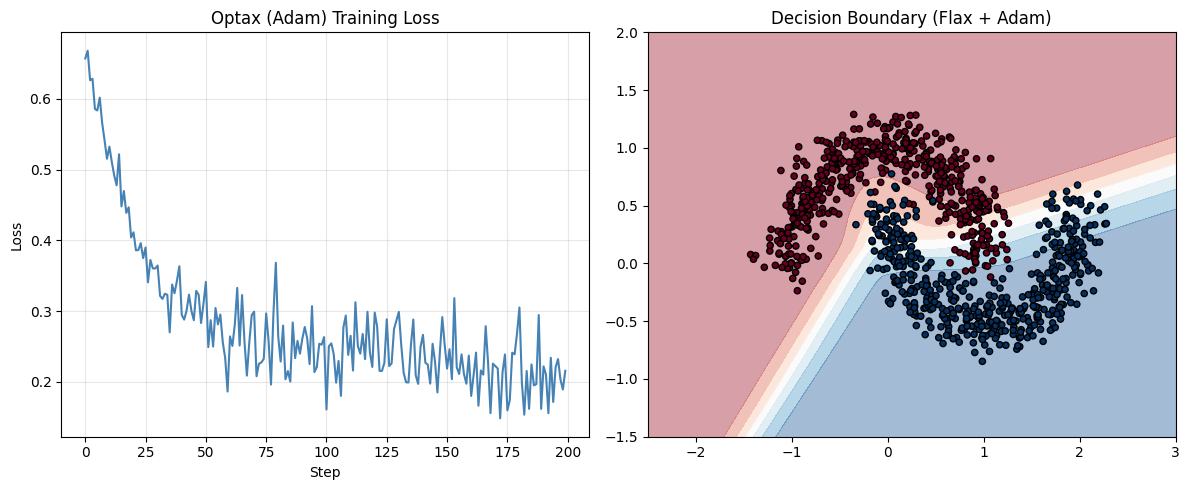

In [5]:
# @title Loss curve and decision boundary { display-mode: "form" }
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss curve (every step)
axes[0].plot(losses_optax, color='steelblue')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')
axes[0].set_title('Optax (Adam) Training Loss'); axes[0].grid(alpha=0.3)

# Decision boundary from Optax-trained model
xx, yy = np.meshgrid(np.linspace(-2.5, 3, 200), np.linspace(-1.5, 2, 200))
grid = jnp.array(np.c_[xx.ravel(), yy.ravel()], dtype=jnp.float32)
logits = model.apply({'params': params_optax}, grid)
probs = jax.nn.sigmoid(logits).reshape(xx.shape)

axes[1].contourf(xx, yy, np.array(probs), alpha=0.4, cmap='RdBu')
axes[1].scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='RdBu', edgecolors='k', s=20)
axes[1].set_title('Decision Boundary (Flax + Adam)')
plt.tight_layout(); plt.show()

---

# 2. Summary

## Key Takeaways

- **Optimizers are purely functional**: the optimizer object describes *the rule*; `opt_state` holds *the running state*. You always pass `opt_state` in and get a new one back.

- **Optimizer state is a pytree**: `opt_state = optimizer.init(params)` returns a structure holding things like momentum buffers and running averages, mirroring the params tree.

- **Updates happen in two steps**: first `updates, new_opt_state = optimizer.update(grads, opt_state)` calculates the parameter deltas, then `new_params = optax.apply_updates(params, updates)` applies them.

- **The training loop body is `loss → grads → update → apply_updates`**: every Optax optimizer (Adam, AdamW, SGD with momentum, schedules, gradient clipping) drops into the same four lines.

## What's Next

In **Notebook 10: Sharding and Multi-Device**, we'll scale beyond a single device: shard arrays across multiple accelerators, parallelize training, and see how JAX's `Mesh` and `NamedSharding` abstractions integrate with the same Flax + Optax training loop you just built.

## Further Reading

- **[Optax docs](https://optax.readthedocs.io/)**: Adam, AdamW, cosine schedules, gradient clipping

- **[Flax training guides](https://flax.readthedocs.io/en/latest/guides/training_techniques/)**: multi-device training, dropout, batch normalization

- **[MaxText](https://github.com/AI-Hypercomputer/maxtext)**: a reference LLM implementation, these patterns at scale

---

# 3. Exercises

1. **Switch optimizer**: Replace `optax.adam` with `optax.sgd(learning_rate=0.05, momentum=0.9)`. Momentum=0.9 means "each update is 90% the previous update plus 10% the new gradient", which smooths out noisy steps. How does convergence compare to Adam?

2. **AdamW**: Train the model with `optax.adamw(learning_rate=1e-3, weight_decay=1e-4)` instead of `adam`. The `weight_decay` term gently shrinks weights toward zero each step (regularization). Compare the final loss against plain Adam.

3. **Inspect the pytree**: After training with Optax, print the shapes and values of the first layer's weights and biases. Verify they differ from initialization.